# DesertMap Logistic Regression Baseline

This notebook trains a Logistic Regression baseline to predict `LILATracts_1And10` using the cleaned modeling dataset. The outputs establish comparison metrics for later model development.

## Section 0: Setup

This section loads the cleaned modeling data, removes the tract identifier, and checks the target balance before modeling.

In [1]:
from pathlib import Path
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    average_precision_score,
)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')
np.random.seed(42)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = PROJECT_ROOT / 'data/processed/modeling_data_clean.csv'
FIGURE_DIR = PROJECT_ROOT / 'outputs/figures'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_FEATURES = [
    'MedianFamilyIncome',
    'PovertyRate',
    'pct_nhblack10',
    'pct_hisp10',
    'pct_nhwhite10',
    'pct_hunv10',
    'pct_snap16',
    'Pop2010',
    'Urban',
]
TARGET_COL = 'LILATracts_1And10'
FIPS_CANDIDATES = ['CensusTract', 'TractFIPS', 'FIPS']

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Missing required data file: {DATA_PATH}')

modeling_data = pd.read_csv(DATA_PATH)

missing_required_columns = [col for col in MODEL_FEATURES + [TARGET_COL] if col not in modeling_data.columns]
if missing_required_columns:
    raise KeyError(f'Missing required columns: {missing_required_columns}')

fips_col = next((col for col in FIPS_CANDIDATES if col in modeling_data.columns), None)
if fips_col is None:
    raise KeyError(f'No FIPS identifier column found. Tried: {FIPS_CANDIDATES}')

modeling_data = modeling_data.drop(columns=[fips_col])

print(f'Dataset shape after dropping {fips_col}: {modeling_data.shape[0]:,} rows x {modeling_data.shape[1]:,} columns')
print('Class balance:')
print(modeling_data[TARGET_COL].value_counts(normalize=True).rename('proportion').to_frame())

Dataset shape after dropping CensusTract: 72,531 rows x 10 columns
Class balance:
                   proportion
LILATracts_1And10            
0                    0.871875
1                    0.128125


## Section 1: Train/Test Split and Scaling

The split is stratified so the food desert rate stays similar in both samples. The scaler is fit only on the training data to prevent information from the test set from leaking into model training.

In [2]:
X = modeling_data[MODEL_FEATURES]
y = modeling_data[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

print(f'Train size: {X_train.shape[0]:,} rows')
print(f'Test size: {X_test.shape[0]:,} rows')
print('\nTrain class balance:')
print(y_train.value_counts(normalize=True).rename('proportion').to_frame())
print('\nTest class balance:')
print(y_test.value_counts(normalize=True).rename('proportion').to_frame())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train size: 58,024 rows
Test size: 14,507 rows

Train class balance:
                   proportion
LILATracts_1And10            
0                    0.871881
1                    0.128119

Test class balance:
                   proportion
LILATracts_1And10            
0                    0.871855
1                    0.128145


## Section 2: Logistic Regression Training

This baseline uses class-balanced Logistic Regression so the minority class receives more weight during training.

In [3]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    solver='lbfgs',
)

start_time = time.perf_counter()
log_reg.fit(X_train_scaled, y_train)
training_time = time.perf_counter() - start_time

print(f'Training time: {training_time:.3f} seconds')

coef_table = pd.DataFrame({
    'feature': MODEL_FEATURES,
    'coefficient': log_reg.coef_[0],
})
coef_table['abs_coefficient'] = coef_table['coefficient'].abs()
coef_table_sorted = coef_table.sort_values('abs_coefficient', ascending=False).reset_index(drop=True)
coef_table_sorted

Training time: 0.026 seconds


,feature,coefficient,abs_coefficient
0,MedianFamilyIncome,-2.060928,2.060928
1,pct_hunv10,-0.624421,0.624421
2,Urban,0.541906,0.541906
3,PovertyRate,0.497946,0.497946
4,pct_hisp10,-0.289331,0.289331
5,pct_nhwhite10,0.217634,0.217634
6,pct_nhblack10,0.166805,0.166805
7,Pop2010,0.117778,0.117778
8,pct_snap16,-0.061537,0.061537


The top three coefficients have the strongest influence after scaling because all inputs are measured on a comparable standard-deviation scale. Positive coefficients increase the predicted probability of a food desert, while negative coefficients decrease it.

In [4]:
top_three = coef_table_sorted.head(3).copy()
for _, row in top_three.iterrows():
    direction = 'increases' if row['coefficient'] > 0 else 'decreases'
    print(
        f"{row['feature']}: coefficient {row['coefficient']:.3f}; "
        f"higher values {direction} the predicted probability of being a food desert."
    )

MedianFamilyIncome: coefficient -2.061; higher values decreases the predicted probability of being a food desert.
pct_hunv10: coefficient -0.624; higher values decreases the predicted probability of being a food desert.
Urban: coefficient 0.542; higher values increases the predicted probability of being a food desert.


## Section 3: Model Evaluation

Evaluation uses held-out test data only, with both threshold-based and probability-based metrics.

### 3a. Classification Report

The classification report summarizes precision, recall, and F1-score for each class at the default decision threshold.

In [5]:
y_pred = log_reg.predict(X_test_scaled)
y_score = log_reg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Not food desert', 'Food desert']))

roc_auc = roc_auc_score(y_test, y_score)
average_precision = average_precision_score(y_test, y_score)

print(f'ROC-AUC: {roc_auc:.3f}')
print(f'Average Precision: {average_precision:.3f}')

                 precision    recall  f1-score   support

Not food desert       0.96      0.73      0.83     12648
    Food desert       0.30      0.80      0.44      1859

       accuracy                           0.74     14507
      macro avg       0.63      0.76      0.63     14507
   weighted avg       0.88      0.74      0.78     14507

ROC-AUC: 0.838
Average Precision: 0.385


### 3b. Confusion Matrix

The confusion matrix shows how often test tracts are correctly or incorrectly assigned to each class.

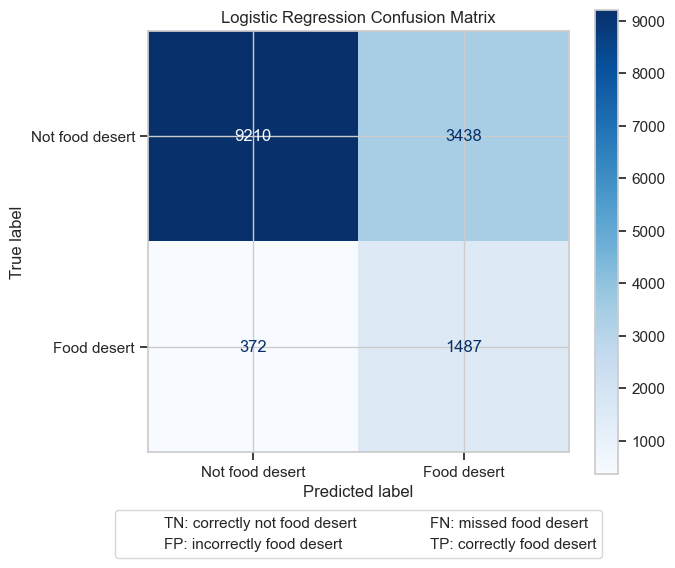

In [6]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not food desert', 'Food desert'],
)
disp.plot(cmap='Blues', values_format='d', ax=ax, colorbar=True)
ax.set_title('Logistic Regression Confusion Matrix')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
for label in ['TN: correctly not food desert', 'FP: incorrectly food desert', 'FN: missed food desert', 'TP: correctly food desert']:
    ax.plot([], [], linestyle='none', label=label)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=True)
fig.tight_layout()
fig.savefig(FIGURE_DIR / '03_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

True negatives are tracts correctly predicted as not food deserts, and true positives are tracts correctly predicted as food deserts. A false negative is more harmful here because it misses a tract that actually has limited food access, while a false positive mainly sends extra attention to a tract that may not need it as urgently.

### 3c. ROC and Precision-Recall Curves

These curves evaluate ranking quality across decision thresholds rather than relying on one cutoff.

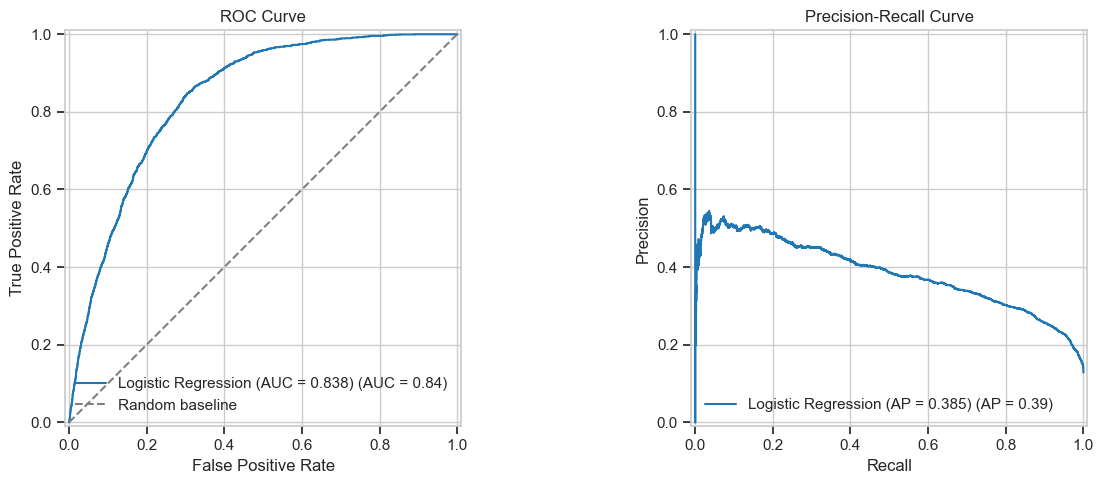

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_score,
    name=f'Logistic Regression (AUC = {roc_auc:.3f})',
    ax=axes[0],
)
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random baseline')
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_score,
    name=f'Logistic Regression (AP = {average_precision:.3f})',
    ax=axes[1],
)
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left')

fig.tight_layout()
fig.savefig(FIGURE_DIR / '03_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 4: Coefficient Analysis

Coefficient signs show whether each standardized feature pushes the model toward or away from predicting a food desert.

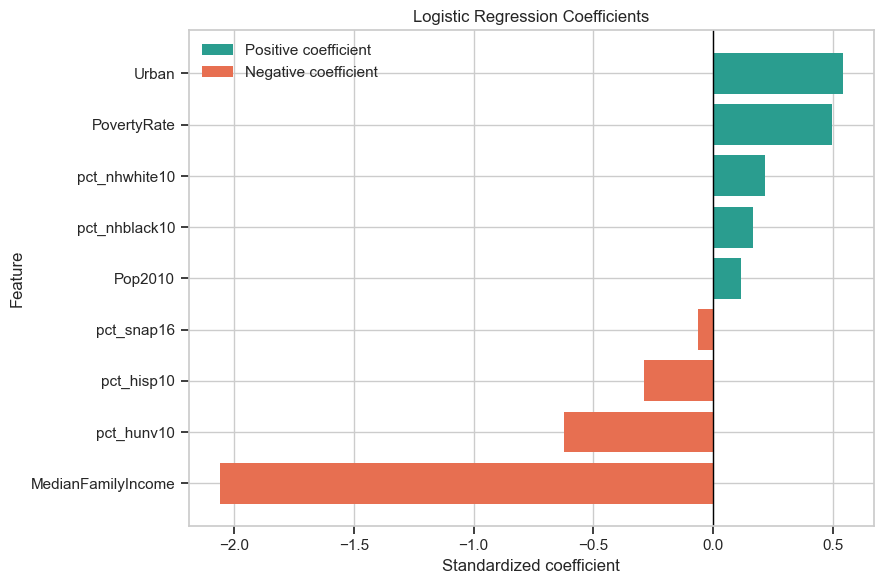

In [8]:
coef_by_value = coef_table.sort_values('coefficient', ascending=True).reset_index(drop=True)
coef_colors = np.where(coef_by_value['coefficient'] >= 0, '#2A9D8F', '#E76F51')

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(coef_by_value['feature'], coef_by_value['coefficient'], color=coef_colors)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Logistic Regression Coefficients')
ax.set_xlabel('Standardized coefficient')
ax.set_ylabel('Feature')
ax.legend(
    handles=[
        Patch(facecolor='#2A9D8F', label='Positive coefficient'),
        Patch(facecolor='#E76F51', label='Negative coefficient'),
    ],
    loc='best',
)
fig.tight_layout()
fig.savefig(FIGURE_DIR / '03_logistic_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

`pct_nhblack10` and `pct_hisp10` should be checked against the top three most positive coefficients because their presence there would mean demographic composition is strongly pushing predictions toward the food desert class. This is a preview of the Week 6 fairness audit, where the project will evaluate whether the model's decision logic creates uneven impacts across communities.

In [9]:
top_positive_features = coef_table.sort_values('coefficient', ascending=False).head(3)['feature'].tolist()
fairness_preview_features = ['pct_nhblack10', 'pct_hisp10']
features_in_top_positive = [feature for feature in fairness_preview_features if feature in top_positive_features]

print(f'Top 3 most positive coefficients: {top_positive_features}')
if features_in_top_positive:
    print(
        f"Fairness preview: {features_in_top_positive} appear in the top 3 most positive coefficients, "
        'so race or ethnicity variables are among the strongest factors pushing predictions toward food desert.'
    )
else:
    print(
        'Fairness preview: pct_nhblack10 and pct_hisp10 do not appear in the top 3 most positive coefficients, '
        'so they are not the strongest positive drivers in this baseline.'
    )

Top 3 most positive coefficients: ['Urban', 'PovertyRate', 'pct_nhwhite10']
Fairness preview: pct_nhblack10 and pct_hisp10 do not appear in the top 3 most positive coefficients, so they are not the strongest positive drivers in this baseline.


## Section 5: Baseline Metrics Summary

The final metrics table is saved for direct comparison with the Random Forest model in the next notebook.

In [10]:
report = classification_report(
    y_test,
    y_pred,
    target_names=['Not food desert', 'Food desert'],
    output_dict=True,
)

baseline_metrics = {
    'Accuracy': report['accuracy'],
    'Precision (food desert class)': report['Food desert']['precision'],
    'Recall (food desert class)': report['Food desert']['recall'],
    'F1 (food desert class)': report['Food desert']['f1-score'],
    'ROC-AUC': roc_auc,
    'Average Precision': average_precision,
}

metrics_summary = pd.DataFrame(
    baseline_metrics.items(),
    columns=['Metric', 'Value'],
)
display(metrics_summary.style.format({'Value': '{:.3f}'}))

with open(OUTPUT_DIR / 'baseline_metrics.json', 'w') as metrics_file:
    json.dump(baseline_metrics, metrics_file, indent=2)

print('Baseline (Logistic Regression) complete.')
print(
    f"F1 (food desert): {baseline_metrics['F1 (food desert class)']:.3f} | "
    f"ROC-AUC: {baseline_metrics['ROC-AUC']:.3f}"
)
print('Next: notebooks/04_random_forest.ipynb')

,Metric,Value
0,Accuracy,0.737
1,Precision (food desert class),0.302
2,Recall (food desert class),0.800
3,F1 (food desert class),0.438
4,ROC-AUC,0.838
5,Average Precision,0.385


Baseline (Logistic Regression) complete.
F1 (food desert): 0.438 | ROC-AUC: 0.838
Next: notebooks/04_random_forest.ipynb
